# Day 3 – SQL via Python: NYC School Data Exploration

In this notebook, I connect to a PostgreSQL database and run SQL queries in Python to explore NYC school data.

The analysis focuses on:
- school distribution across boroughs
- average percentage of English Language Learners (ELL) per borough
- top 3 schools in each borough with the highest percentage of special education students

In [2]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt

## Database Connection

I connect to the PostgreSQL onboarding database using `psycopg2`.

In [3]:
conn = psycopg2.connect(
    dbname="neondb",
    user="neondb_owner",
    password="my_password",
    host="ep-falling-glitter-a5m0j5gk-pooler.us-east-2.aws.neon.tech",
    port="5432",
    sslmode="require"
)
cur = conn.cursor()

In [4]:
query_test = "SELECT * FROM nyc_schools.high_school_directory LIMIT 5;"
df_test = pd.read_sql(query_test, conn)
df_test.head()

/tmp/ipykernel_346/301060012.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_test = pd.read_sql(query_test, conn)


,dbn,school_name,borough,building_code,phone_number,fax_number,grade_span_min,grade_span_max,expgrade_span_min,expgrade_span_max,...,number_programs,Location 1,Community Board,Council District,Census Tract,Zip Codes,Community Districts,Borough Boundaries,City Council Districts,Police Precincts
0,27Q260,Frederick Douglass Academy VI High School,Queens,Q465,718-471-2154,718-471-2890,9.0,12,None,None,...,1,"{'latitude': '40.601989336', 'longitude': '-73...",14,31,100802,20529,51,3,47,59
1,21K559,Life Academy High School for Film and Music,Brooklyn,K400,718-333-7750,718-333-7775,9.0,12,None,None,...,1,"{'latitude': '40.593593811', 'longitude': '-73...",13,47,306,17616,21,2,45,35
2,16K393,Frederick Douglass Academy IV Secondary School,Brooklyn,K026,718-574-2820,718-574-2821,9.0,12,None,None,...,1,"{'latitude': '40.692133704', 'longitude': '-73...",3,36,291,18181,69,2,49,52
3,08X305,Pablo Neruda Academy,Bronx,X450,718-824-1682,718-824-1663,9.0,12,None,None,...,1,"{'latitude': '40.822303765', 'longitude': '-73...",9,18,16,11611,58,5,31,26
4,03M485,Fiorello H. LaGuardia High School of Music & A...,Manhattan,M485,212-496-0700,212-724-5748,9.0,12,None,None,...,6,"{'latitude': '40.773670507', 'longitude': '-73...",7,6,151,12420,20,4,19,12


## Question 1: How many schools are there in each borough?

This query counts the number of schools in each borough using the `high_school_directory` table.

In [5]:
query_1 = """
SELECT
    borough,
    COUNT(DISTINCT dbn) AS school_count
FROM nyc_schools.high_school_directory
GROUP BY borough
ORDER BY school_count DESC;
"""

df_schools = pd.read_sql(query_1, conn)
df_schools

/tmp/ipykernel_346/1214328497.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_schools = pd.read_sql(query_1, conn)


,borough,school_count
0,Brooklyn,121
1,Bronx,118
2,Manhattan,106
3,Queens,80
4,Staten Island,10


## Visualization: Number of Schools per Borough

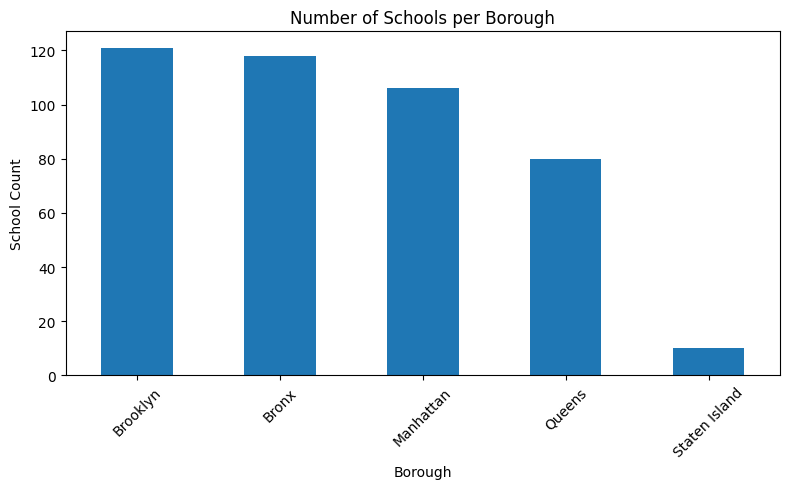

In [6]:
df_schools.plot(
    kind="bar",
    x="borough",
    y="school_count",
    legend=False,
    figsize=(8, 5)
)

plt.title("Number of Schools per Borough")
plt.xlabel("Borough")
plt.ylabel("School Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Question 2: What is the average percentage of English Language Learners (ELL) per borough?

This query joins `school_demographics` and `high_school_directory` using `dbn` and calculates the average `ell_percent` per borough.

In [7]:
query_2 = """
SELECT
    h.borough,
    ROUND(AVG(CAST(d.ell_percent AS NUMERIC)), 2) AS avg_ell_percent
FROM nyc_schools.school_demographics d
JOIN nyc_schools.high_school_directory h
    ON d.dbn = h.dbn
WHERE d.ell_percent IS NOT NULL
GROUP BY h.borough
ORDER BY avg_ell_percent DESC;
"""

df_ell = pd.read_sql(query_2, conn)
df_ell

/tmp/ipykernel_346/1212123045.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_ell = pd.read_sql(query_2, conn)


,borough,avg_ell_percent
0,Manhattan,7.57


## Question 3: Top 3 schools in each borough with the highest percentage of special education students

This query ranks schools within each borough by `sped_percent` and returns the top 3 schools per borough.

In [8]:
query_3 = """
WITH ranked_schools AS (
    SELECT
        h.borough,
        h.school_name,
        d.sped_percent,
        ROW_NUMBER() OVER (
            PARTITION BY h.borough
            ORDER BY d.sped_percent DESC
        ) AS rank_in_borough
    FROM nyc_schools.school_demographics d
    JOIN nyc_schools.high_school_directory h
        ON d.dbn = h.dbn
    WHERE d.sped_percent IS NOT NULL
)
SELECT
    borough,
    school_name,
    sped_percent,
    rank_in_borough
FROM ranked_schools
WHERE rank_in_borough <= 3
ORDER BY borough, rank_in_borough;
"""

df_sped = pd.read_sql(query_3, conn)
df_sped

/tmp/ipykernel_346/1915015958.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sped = pd.read_sql(query_3, conn)


,borough,school_name,sped_percent,rank_in_borough
0,Manhattan,East Side Community School,28.8,1
1,Manhattan,East Side Community School,27.7,2
2,Manhattan,East Side Community School,26.7,3


## Insights

- Brooklyn has the highest number of schools in the dataset, followed by the Bronx and Manhattan.
- The average percentage of English Language Learners varies across boroughs, which suggests different language support needs across student populations.
- The schools with the highest `sped_percent` differ by borough, showing that special education needs are not evenly distributed.
- Running SQL inside Python is a practical workflow because query results can be directly reviewed and analyzed in pandas.

In [9]:
cur.close()
conn.close()